# 02 — SfM-30k data, DINOv2 smoke checks, pooling pilot, and feature cache

Run this notebook before a full cache. It validates token layout and preprocessing, runs the SfM-only pooling-temperature pilot, then calls the resumable cache script after a temperature is locked.

In [1]:
# Run this first in every fresh Colab runtime.  It intentionally does not use PYTHONPATH.
from datetime import datetime, timezone
from pathlib import Path
import importlib
import os
import shutil
import subprocess
import sys

# Override this only if you use a fork/private clone URL.
REPO_URL = os.environ.get('CBIR_REPO_URL', 'https://github.com/armin-faraji/LightweightCBIR.git')
REPO_REVISION = os.environ.get('CBIR_REPO_REVISION', 'main')
PROJECT_ROOT = Path('/content/lightweight-cbir')
if not PROJECT_ROOT.is_dir():
    if not REPO_URL:
        raise RuntimeError('Set CBIR_REPO_URL before first use, or clone the repository to /content/lightweight-cbir.')
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', REPO_REVISION], check=True)
os.chdir(PROJECT_ROOT)
required_project_files = (PROJECT_ROOT / 'pyproject.toml', PROJECT_ROOT / 'src' / 'cbir' / '__init__.py', PROJECT_ROOT / 'src' / 'cbir' / 'artifacts.py')
missing_project_files = [str(path.relative_to(PROJECT_ROOT)) for path in required_project_files if not path.is_file()]
if missing_project_files:
    raise RuntimeError('The cloned repository does not contain the Colab-ready project code: ' + ', '.join(missing_project_files) + '. Push the current repository, or set CBIR_REPO_URL/CBIR_REPO_REVISION to the matching commit.')
# A regular reinstall is intentional: PEP 660 editable .pth files are read
# only when a Jupyter kernel starts, so a just-installed editable package can
# still be invisible in this same first cell.
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps', '--force-reinstall', '.'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'h5py', 'scipy', 'PyYAML', 'tqdm', 'matplotlib', 'Pillow'], check=True)

importlib.invalidate_caches()
try:
    import cbir
except ModuleNotFoundError as error:
    raise RuntimeError('The package installation completed but cbir is not visible to this kernel. Restart the runtime once, then rerun this first cell.') from error
print('cbir package:', cbir.__file__)

from cbir.artifacts import create_artifact_run, make_artifact_run_id
from cbir.backbone import FrozenDinoV2Extractor
from cbir.cloud import mount_colab_drive, runtime_report, write_runtime_report
from cbir.config import config_to_dict, load_project_config
from cbir.data.sfm import Sfm30kMetadata, SfmImageDirectoryReader, SfmMatImageReader
from cbir.features import FeatureExtractionRunner
from cbir.plotting import SeriesData, plot_series
from cbir.utils import stable_hash

PERSISTENT_ROOT = mount_colab_drive() / 'lightweight-cbir'
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TORCH_HOME', str(PERSISTENT_ROOT / 'torch_hub'))
CONFIG_PATH = Path('configs/colab.yaml')
cfg = load_project_config(CONFIG_PATH)
environment = runtime_report(project_root=PROJECT_ROOT)
config_fingerprint = stable_hash(config_to_dict(cfg))
RUN_ID = make_artifact_run_id(notebook='02', git_sha=environment['git_sha'], config_fingerprint=config_fingerprint)
ARTIFACT_RUN = create_artifact_run(PROJECT_ROOT / 'outputs', '02', run_id=RUN_ID, metadata={'git_sha': environment['git_sha'], 'config_fingerprint': config_fingerprint})
LOCAL_OUTPUT_DIR = ARTIFACT_RUN.local_dir
DRIVE_OUTPUT_ROOT = PERSISTENT_ROOT / 'notebook_outputs'
write_runtime_report(LOCAL_OUTPUT_DIR, project_root=PROJECT_ROOT, extra={'notebook': '02', 'config': str(CONFIG_PATH)})
shutil.copy2(CONFIG_PATH, ARTIFACT_RUN.path_for('config.yaml'))
print('Project:', PROJECT_ROOT)
print('Artifacts:', LOCAL_OUTPUT_DIR)
print('Config:', cfg)
import torch
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'unavailable')

Mounted at /content/drive
Project: /content/lightweight-cbir
Artifacts: /content/lightweight-cbir/outputs/02/20260802T143814Z__nb-02__git-23f9838cef89__cfg-fe7b5fb092a1
Config: ProjectConfig(backbone=BackboneConfig(repo='facebookresearch/dinov2', entrypoint='dinov2_vits14_reg', revision='7764ea0f912e53c92e82eb78a2a1631e92725fc8', checkpoint_id=None, token_dim=384, num_blocks=12, patch_size=14, num_register_tokens=4, device='cuda', use_amp=True), preprocess=PreprocessConfig(long_side=224, patch_size=14, interpolation='bicubic', antialias=True, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), rgb_only=True, extreme_aspect_policy='crop_long_axis'), pooling=PoolingConfig(temperature=0.1, eps=1e-12, aggregation_version='v1', all_layer_indices=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)), cache=FeatureCacheConfig(local_root=PosixPath('/content/cbir_cache'), drive_root=PosixPath('/content/drive/MyDrive/lightweight-cbir/feature_caches'), shard_size=250, feature_dtype='float16', entropy_dtype=

## Phase 0: square/rectangular token smoke test

This must show a 16×16 patch grid for 224×224 and a 16×10 grid for 224×140. The official intermediate API should return genuine patches only; the adapter asserts the register-token convention.

In [2]:
extractor = FrozenDinoV2Extractor(cfg.backbone)
for hw in [(224, 224), (224, 140)]:
    x = torch.randn(1, 3, *hw)
    outputs = extractor.extract_intermediate_tokens(x, (3, 7, 11))
    print(hw, [(item.block_index, item.patch_grid_hw, tuple(item.patches.shape)) for item in outputs])

Using cache found in /content/drive/MyDrive/lightweight-cbir/torch_hub/hub/facebookresearch_dinov2_7764ea0f912e53c92e82eb78a2a1631e92725fc8
/content/drive/MyDrive/lightweight-cbir/torch_hub/hub/facebookresearch_dinov2_7764ea0f912e53c92e82eb78a2a1631e92725fc8/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/content/drive/MyDrive/lightweight-cbir/torch_hub/hub/facebookresearch_dinov2_7764ea0f912e53c92e82eb78a2a1631e92725fc8/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/content/drive/MyDrive/lightweight-cbir/torch_hub/hub/facebookresearch_dinov2_7764ea0f912e53c92e82eb78a2a1631e92725fc8/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


(224, 224) [(3, (16, 16), (1, 256, 384)), (7, (16, 16), (1, 256, 384)), (11, (16, 16), (1, 256, 384))]
(224, 140) [(3, (16, 10), (1, 160, 384)), (7, (16, 10), (1, 160, 384)), (11, (16, 10), (1, 160, 384))]


## Phase 0b: end-to-end integration smoke run

This is deliberately a tiny non-benchmark run. It uses real DINOv2 on generated images, writes and reads a temporary feature cache, trains the RGMF head for two epochs, reloads its checkpoint, and runs SfM-style plus synthetic RevisitOP evaluation. Its purpose is to catch interface, cache, device, and checkpoint mistakes before downloading or processing SfM-30k. Its scores have no scientific meaning.

In [3]:
from dataclasses import replace
from pathlib import Path
from tempfile import TemporaryDirectory

from PIL import Image, ImageDraw

from cbir.cache import FeatureManifest, FeatureShardReader, FeatureShardWriter, validate_feature_cache
from cbir.config import FeatureCacheConfig, FusionConfig, TrainingConfig
from cbir.data.revisitop import RevisitGroundTruth, crop_revisit_query
from cbir.data.sfm import ImageRecord, PairRecord, ValidationCase
from cbir.evaluation import (
    descriptors_from_cache,
    descriptors_from_images,
    evaluate_revisitop,
    evaluate_sfm_verified_pairs,
    ranked_ids_from_descriptors,
)
from cbir.fusion import ReliabilityGatedFusion
from cbir.training import HeadTrainer
from cbir.utils import hash_strings

def toy_landmark(color, shift=0):
    image = Image.new('RGB', (190, 130), (238, 238, 238))
    draw = ImageDraw.Draw(image)
    draw.rectangle((35 + shift, 20, 145 + shift, 112), fill=color, outline=(20, 20, 20), width=4)
    draw.ellipse((75 + shift, 45, 110 + shift, 80), fill=(250, 250, 250))
    return image

def toy_query(color):
    image = Image.new('RGB', (240, 160), (245, 245, 245))
    draw = ImageDraw.Draw(image)
    draw.rectangle((55, 32, 180, 138), fill=color, outline=(20, 20, 20), width=4)
    draw.ellipse((100, 65, 138, 103), fill=(250, 250, 250))
    return image, (55, 32, 180, 138)

# Two train clusters and two disjoint validation clusters; one confirmed pair per cluster.
specs = [
    ('train_red_q', (205, 45, 45), 0, 'train', 0),
    ('train_red_p', (205, 45, 45), 0, 'train', 4),
    ('train_blue_q', (45, 70, 205), 1, 'train', 0),
    ('train_blue_p', (45, 70, 205), 1, 'train', -4),
    ('val_green_q', (45, 160, 75), 2, 'val', 0),
    ('val_green_p', (45, 160, 75), 2, 'val', 4),
    ('val_gold_q', (205, 160, 35), 3, 'val', 0),
    ('val_gold_p', (205, 160, 35), 3, 'val', -4),
]
smoke_images = [(image_id, toy_landmark(color, shift)) for image_id, color, _, _, shift in specs]
smoke_records = {
    image_id: ImageRecord(image_id, split=split, cluster_id=cluster)
    for image_id, _, cluster, split, _ in specs
}
smoke_train_pairs = (
    PairRecord('train_red_q', 'train_red_p', 0, 'train'),
    PairRecord('train_blue_q', 'train_blue_p', 1, 'train'),
)
smoke_val_ids = ('val_green_q', 'val_green_p', 'val_gold_q', 'val_gold_p')
smoke_val_cases = (
    ValidationCase('val_green_q', 'val_green_p', 2, frozenset({'val_green_q'})),
    ValidationCase('val_gold_q', 'val_gold_p', 3, frozenset({'val_gold_q'})),
)

runner = FeatureExtractionRunner(extractor, cfg.preprocess, cfg.pooling)
smoke_features = runner.extract_images(
    smoke_images,
    layer_indices=cfg.pooling.all_layer_indices,
    backbone_batch_size=4,
)

with TemporaryDirectory(prefix='cbir-smoke-') as temporary_name:
    cache_dir = Path(temporary_name) / 'cache'
    smoke_ids = tuple(image_id for image_id, _ in smoke_images)
    manifest = FeatureManifest(
        fingerprint='integration-smoke-v1',
        dataset_name='generated-smoke',
        source_ids_hash=hash_strings(smoke_ids),
        extraction_config={'purpose': 'integration-smoke'},
        layer_indices=cfg.pooling.all_layer_indices,
        token_dim=cfg.backbone.token_dim,
        feature_dtype='float16',
        entropy_dtype='float32',
        expected_image_ids=smoke_ids,
    )
    writer = FeatureShardWriter(
        cache_dir,
        manifest,
        FeatureCacheConfig(local_root=cache_dir, shard_size=len(smoke_ids)),
    )
    writer.write_shard(smoke_features, smoke_records)
    writer.finalize()
    assert validate_feature_cache(cache_dir)['valid']

    cache_reader = FeatureShardReader(cache_dir)
    smoke_fusion = FusionConfig(
        token_dim=cfg.backbone.token_dim,
        layer_indices=(3, 7, 11),
        output_dim=32,
        local_kind='cls_guided_patch',
        gate_mode='reliability',
    )
    smoke_training = TrainingConfig(
        seed=7,
        batch_size=2,
        epochs=2,
        learning_rate=1e-3,
        loss_temperature=0.07,
        early_stopping_patience=2,
        device=cfg.backbone.device,
    )
    head = ReliabilityGatedFusion.from_config(smoke_fusion)
    trainer = HeadTrainer(
        head=head,
        reader=cache_reader,
        train_pairs=smoke_train_pairs,
        fusion_config=smoke_fusion,
        training_config=smoke_training,
        validation_cases=smoke_val_cases,
        validation_image_ids=smoke_val_ids,
        output_dir=cache_dir / 'run',
    )
    history = trainer.fit()
    assert history.best_checkpoint is not None and history.best_checkpoint.is_file()

    checkpoint = torch.load(history.best_checkpoint, map_location='cpu', weights_only=False)
    reloaded_head = ReliabilityGatedFusion.from_config(smoke_fusion)
    reloaded_head.load_state_dict(checkpoint['model_state_dict'])
    val_descriptors = descriptors_from_cache(
        cache_reader,
        reloaded_head,
        smoke_val_ids,
        layer_indices=smoke_fusion.layer_indices,
        local_kind=smoke_fusion.local_kind,
        device=cfg.backbone.device,
    )
    sfm_report = evaluate_sfm_verified_pairs(val_descriptors, smoke_val_ids, smoke_val_cases)

    revisit_database_ids = ('rev_red_easy', 'rev_red_hard', 'rev_blue_easy', 'rev_blue_hard')
    revisit_database_images = [
        ('rev_red_easy', toy_landmark((205, 45, 45), 0)),
        ('rev_red_hard', toy_landmark((205, 45, 45), 5)),
        ('rev_blue_easy', toy_landmark((45, 70, 205), 0)),
        ('rev_blue_hard', toy_landmark((45, 70, 205), -5)),
    ]
    red_query, red_box = toy_query((205, 45, 45))
    blue_query, blue_box = toy_query((45, 70, 205))
    revisit_query_ids = ('rev_red_query', 'rev_blue_query')
    revisit_query_images = [
        ('rev_red_query', crop_revisit_query(red_query, red_box)),
        ('rev_blue_query', crop_revisit_query(blue_query, blue_box)),
    ]
    database_descriptors = descriptors_from_images(
        runner, reloaded_head, revisit_database_images,
        layer_indices=smoke_fusion.layer_indices,
        local_kind=smoke_fusion.local_kind,
        backbone_batch_size=4,
        device=cfg.backbone.device,
    )
    query_descriptors = descriptors_from_images(
        runner, reloaded_head, revisit_query_images,
        layer_indices=smoke_fusion.layer_indices,
        local_kind=smoke_fusion.local_kind,
        backbone_batch_size=2,
        device=cfg.backbone.device,
    )
    rankings = ranked_ids_from_descriptors(query_descriptors, database_descriptors, revisit_database_ids)
    revisit_report = evaluate_revisitop(
        rankings,
        revisit_query_ids,
        {
            'rev_red_query': RevisitGroundTruth('rev_red_query', frozenset({'rev_red_easy'}), frozenset({'rev_red_hard'}), frozenset()),
            'rev_blue_query': RevisitGroundTruth('rev_blue_query', frozenset({'rev_blue_easy'}), frozenset({'rev_blue_hard'}), frozenset()),
        },
    )
    assert 0.0 <= revisit_report.medium.map <= 1.0
    assert 0.0 <= revisit_report.hard.map <= 1.0

print('Integration smoke test passed.')
print('Toy SfM validation:', sfm_report)
print('Toy RevisitOP Medium/Hard mAP:', revisit_report.medium.map, revisit_report.hard.map)

Integration smoke test passed.
Toy SfM validation: SfmRetrievalReport(num_queries=2, recall_at_1=1.0, recall_at_5=1.0, recall_at_10=1.0, mrr=1.0, ranks={'val_green_q': 1, 'val_gold_q': 1})
Toy RevisitOP Medium/Hard mAP: 0.6458333333333333 0.5833333333333334


## Phase 0c: actual Drive cache round trip

Unlike Phase 0b, this verifies the mounted Drive path: a small completed cache is published, removed locally, restored into a new local path, and revalidated. The temporary Drive cache is removed only after this assertion succeeds.

In [4]:
import shutil
from tempfile import TemporaryDirectory

from cbir.cache import CacheResolver, FeatureManifest, FeatureShardWriter, validate_feature_cache
from cbir.config import FeatureCacheConfig
from cbir.utils import hash_strings

with TemporaryDirectory(prefix='cbir-drive-smoke-') as temporary_name:
    local_cache = Path(temporary_name) / 'local-cache'
    drive_cache = PERSISTENT_ROOT / 'smoke_caches' / ARTIFACT_RUN.run_id
    smoke_ids = tuple(image_id for image_id, _ in smoke_images)
    manifest = FeatureManifest(
        fingerprint='drive-smoke-' + ARTIFACT_RUN.run_id,
        dataset_name='generated-drive-smoke',
        source_ids_hash=hash_strings(smoke_ids),
        extraction_config={'purpose': 'drive-round-trip'},
        layer_indices=cfg.pooling.all_layer_indices,
        token_dim=cfg.backbone.token_dim,
        feature_dtype='float16',
        entropy_dtype='float32',
        expected_image_ids=smoke_ids,
    )
    writer = FeatureShardWriter(local_cache, manifest, FeatureCacheConfig(local_root=local_cache, shard_size=len(smoke_ids)))
    writer.write_shard(smoke_features, smoke_records)
    writer.finalize()
    resolver = CacheResolver(local_cache, drive_cache)
    resolver.mirror_local_to_drive()
    shutil.rmtree(local_cache)
    restored = resolver.resolve_existing(manifest.fingerprint)
    assert restored == local_cache and validate_feature_cache(restored)['valid']
    ARTIFACT_RUN.write_json('drive_cache_round_trip.json', {'status': 'passed', 'cache_fingerprint': manifest.fingerprint})
    shutil.rmtree(drive_cache)
print('Drive cache round trip passed.')

Drive cache round trip passed.


## Stage SfM-30k into this runtime

The compact MAT file is kept persistently on Drive after its first download, then copied to fast `/content` storage for extraction. This cell is idempotent; it does not re-download or overwrite an existing valid local/Drive copy.

In [5]:
# The first run on Google Colab takes a few minutes for the dataset download and Google Drive sync.
# Next times it takes less time.

from cbir.cloud import publish_file, stage_file

LOCAL_SFM_ROOT = cfg.sfm.metadata_path.parent
DRIVE_SFM_ROOT = PERSISTENT_ROOT / 'datasets' / 'sfm30k'
LOCAL_SFM_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_SFM_ROOT.mkdir(parents=True, exist_ok=True)
sfm_files = (
    cfg.sfm.metadata_path,
    cfg.sfm.names_clusters_path,
    cfg.sfm.image_mat_path,
)
if not all(path is not None and path.is_file() for path in sfm_files):
    # Download to Drive on first use: its .part sidecars survive a Colab reset.
    # Then stage the completed files to fast local storage for feature extraction.
    if not all(path is not None and (DRIVE_SFM_ROOT / path.name).is_file() for path in sfm_files):
        subprocess.run([
            sys.executable, 'scripts/prepare_sfm30k.py',
            '--config', str(CONFIG_PATH),
            '--image-source', 'mat',
            '--data-dir', str(DRIVE_SFM_ROOT),
        ], cwd=PROJECT_ROOT, check=True)
    for path in sfm_files:
        assert path is not None
        stage_file(DRIVE_SFM_ROOT / path.name, path)
for path in sfm_files:
    if path is None or not path.is_file():
        raise FileNotFoundError(f'SfM preparation did not create {path}')
    if not (DRIVE_SFM_ROOT / path.name).is_file():
        publish_file(path, DRIVE_SFM_ROOT / path.name)
ARTIFACT_RUN.write_json('sfm_stage.json', {path.name: {'local': str(path), 'drive': str(DRIVE_SFM_ROOT / path.name), 'bytes': path.stat().st_size} for path in sfm_files if path is not None})
print('SfM data staged at', LOCAL_SFM_ROOT)

SfM data staged at /content/cbir_data


## Metadata validation and pooling-temperature pilot

The preceding staging cell fetches/restores the compact SfM-30k source. This pilot uses a deterministic 500-image sample from each split. It computes all candidate temperatures from the same backbone forwards; do not create the full cache until a value is documented and copied into `configs/colab.yaml`. Entropy and guided-vs-mean cosine are screening diagnostics, not retrieval scores: use them to reject nearly uniform or overly sharp temperatures, then confirm the shortlist with SfM validation.

{'images': 28559, 'train_images': 22156, 'val_images': 6403, 'train_clusters': 551, 'val_clusters': 162, 'train_pairs': 28417, 'val_pairs': 1691}


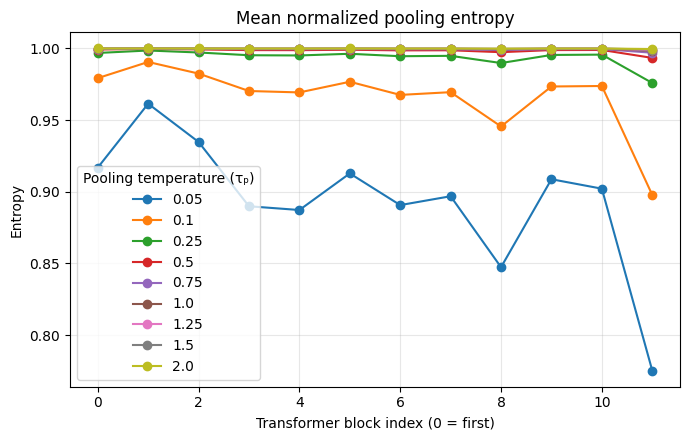

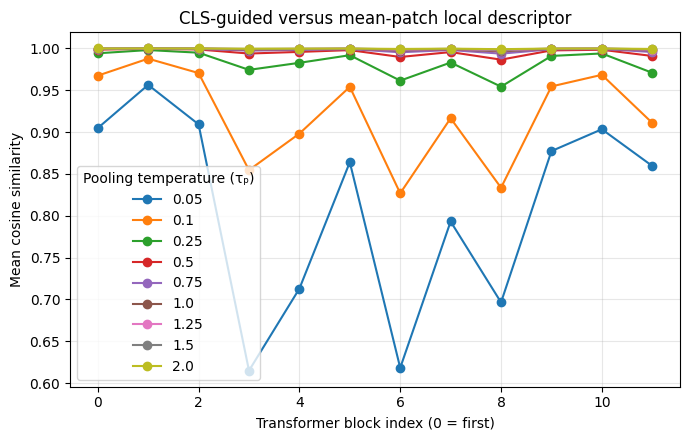

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

# Prevent figures left open by a previous rerun from being implicitly rendered again.
plt.close('all')

metadata = Sfm30kMetadata.from_official_files(cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
print(metadata.validate())
PILOT_PER_SPLIT = 500
BACKBONE_BATCH_SIZE = 8 # Can be increased
records = list(metadata.records('train'))[:PILOT_PER_SPLIT] + list(metadata.records('val'))[:PILOT_PER_SPLIT]

if cfg.sfm.image_root is not None:
    image_reader = SfmImageDirectoryReader(cfg.sfm.image_root)
else:
    image_reader = SfmMatImageReader(cfg.sfm.image_mat_path)
try:
    images = [
        (record.image_id, image_reader.read(record.image_id) if cfg.sfm.image_root is not None else image_reader.read(record.split, int(record.image_locator)))
        for record in records
    ]
finally:
    if isinstance(image_reader, SfmMatImageReader):
        image_reader.close()

runner = FeatureExtractionRunner(extractor, cfg.preprocess, cfg.pooling)
pilot = runner.pilot_pooling_temperatures(
    images,
    temperatures=(0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2),
    backbone_batch_size=BACKBONE_BATCH_SIZE,
)
entropy_series = {
    str(tau): SeriesData(x=list(pilot.layer_indices), y=values.mean(dim=0).tolist())
    for tau, values in pilot.entropy_by_temperature.items()
}
entropy_figure, _ = plot_series(
    entropy_series,
    title='Mean normalized pooling entropy',
    xlabel='Transformer block index (0 = first)',
    ylabel='Entropy',
    legend_title='Pooling temperature (τₚ)',
    save_path=ARTIFACT_RUN.path_for('figures/pooling_entropy_by_temperature.png'),
)
cosine_series = {
    str(tau): SeriesData(x=list(pilot.layer_indices), y=values.mean(dim=0).tolist())
    for tau, values in pilot.guided_mean_cosine_by_temperature.items()
}
cosine_figure, _ = plot_series(
    cosine_series,
    title='CLS-guided versus mean-patch local descriptor',
    xlabel='Transformer block index (0 = first)',
    ylabel='Mean cosine similarity',
    legend_title='Pooling temperature (τₚ)',
    save_path=ARTIFACT_RUN.path_for('figures/pooling_guided_mean_cosine_by_temperature.png'),
)
ARTIFACT_RUN.write_json('pooling_temperature_pilot.json', {
    'temperatures': list(pilot.entropy_by_temperature),
    'layer_indices': list(pilot.layer_indices),
    'images_per_split': PILOT_PER_SPLIT,
    'backbone_batch_size': BACKBONE_BATCH_SIZE,
    'mean_entropy': {str(tau): values.mean(dim=0).tolist() for tau, values in pilot.entropy_by_temperature.items()},
    'mean_guided_mean_cosine': {str(tau): values.mean(dim=0).tolist() for tau, values in pilot.guided_mean_cosine_by_temperature.items()},
})

# Display the two intended, differently titled diagnostics exactly once.
display(entropy_figure)
display(cosine_figure)
plt.close(entropy_figure)
plt.close(cosine_figure)

## Full resumable cache

After recording the chosen pooling temperature in the YAML config, first use the limit-500 command to test cache/Drive recovery. Then omit the limit option. The script checks local cache first, then Drive, and only computes unresolved features.

In [9]:
# Set deliberately: 'none', 'pilot500', or 'full'.  Full extraction resumes validated Drive progress.
EXTRACTION_MODE = 'full'
if EXTRACTION_MODE not in {'none', 'pilot500', 'full'}:
    raise ValueError('EXTRACTION_MODE must be none, pilot500, or full')
if EXTRACTION_MODE != 'none':
    command = [sys.executable, 'scripts/extract_features.py', '--config', str(CONFIG_PATH), '--backbone-batch-size', str(BACKBONE_BATCH_SIZE)]
    if EXTRACTION_MODE == 'pilot500':
        command.extend(['--limit', '500'])
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
    ARTIFACT_RUN.write_json('extraction_command.json', {'command': command, 'mode': EXTRACTION_MODE})
    if EXTRACTION_MODE == 'full':
        from cbir.workflow import full_sfm_cache_location
        from cbir.cache import validate_feature_cache
        location = full_sfm_cache_location(cfg, metadata)
        local_report = validate_feature_cache(location.local_dir, expected_fingerprint=location.fingerprint)
        drive_report = validate_feature_cache(location.drive_dir, expected_fingerprint=location.fingerprint) if location.drive_dir is not None else None
        if not local_report['valid'] or drive_report is None or not drive_report['valid']:
            raise RuntimeError('full cache did not validate both locally and on Drive')
        ARTIFACT_RUN.write_json('full_cache_validation.json', {'cache_name': location.cache_name, 'fingerprint': location.fingerprint, 'local': local_report, 'drive': drive_report})
else:
    print('No extraction launched. Set EXTRACTION_MODE after recording the selected pooling temperature in configs/colab.yaml.')

## Publish notebook outputs to Drive

Run this as the final cell after any smoke, pilot, or extraction action. Feature-cache shards are already checkpointed separately; this publishes report figures and metadata.

In [10]:
published_output = ARTIFACT_RUN.publish(DRIVE_OUTPUT_ROOT)
print('Validated notebook artifacts published to:', published_output)

Validated notebook artifacts published to: /content/drive/MyDrive/lightweight-cbir/notebook_outputs/02/20260802T143814Z__nb-02__git-23f9838cef89__cfg-fe7b5fb092a1__rev-79162caf6d7a
